<a href="https://colab.research.google.com/github/Nancyrana1/Deep-Learning/blob/main/DROPOUT_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Dropout
from sklearn.model_selection import train_test_split

In [10]:
X_train= np.linspace(-1,1,20)
y_train=np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [11]:
X_test = np.linspace(-1,1,20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

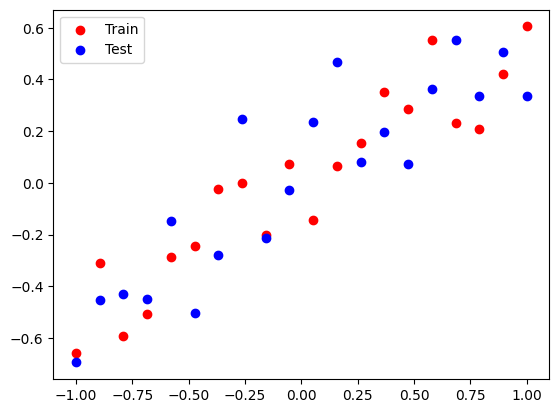

In [12]:
plt.scatter(X_train,y_train,c = 'red',label='Train')
plt.scatter(X_test,y_test,c = 'blue',label='Test')
plt.legend()
plt.show()

REGRESSION MODEL

In [14]:
model = Sequential()
model.add(Dense(128,activation='relu',input_dim=1))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='linear'))

adam=Adam(learning_rate=0.01)
model.compile(optimizer='adam',loss='mse',metrics=['mse'])

history = model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
train_score = model.evaluate(X_train,y_train,verbose=0)
test_score = model.evaluate(X_test,y_test,verbose=0)

print(f'train : {train_score},  test : {test_score}')

train : [0.00900778267532587, 0.00900778267532587],  test : [0.037965208292007446, 0.037965208292007446]


In [16]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [19]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_pred,y_test)

In [20]:
print(accuracy)

0.671746100537872


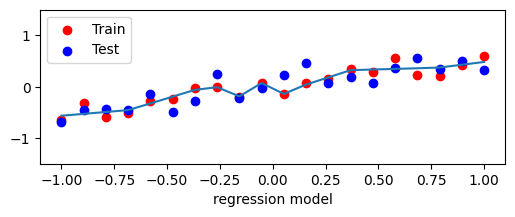

In [23]:
plt.figure(figsize=(6,2))
plt.xlabel('regression model')
plt.scatter(X_train,y_train,c='red',label = 'Train')
plt.scatter(X_test,y_test,c='blue',label = 'Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim((-1.5,1.5))
plt.show()

DROPOUT MODEL

In [27]:
model2=Sequential()
model2.add(Dense(128,activation='relu',input_dim=1))
model2.add(Dropout(0.2))
model2.add(Dense(128,activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1,activation='linear'))
adam = Adam(learning_rate=0.01)
model2.compile(loss='mse',metrics=['mse'],optimizer=adam)
dropout_history = model2.fit(X_train,y_train,validation_data = (X_test,y_test),
                             verbose=False)



In [28]:
train2_loss=model2.evaluate(X_train,y_train,verbose=0)
test2_loss=model2.evaluate(X_test,y_test,verbose=0)
print(f'train_loss : {train2_loss},  test_loss : {test2_loss}')

train_loss : [0.027528267353773117, 0.027528267353773117],  test_loss : [0.03769512102007866, 0.03769512102007866]


In [30]:
y2_pred= model2.predict(X_test)
accuracy = r2_score(y_test,y2_pred)
accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


0.7280441189065386